In [1]:
import pandas as pd

data = pd.read_csv(
    "2315676.txt",
    sep=r"\s+",
    na_values=-9999
)
#just to check
data.head()
data.tail()
data.columns

Index(['STATION', 'STATION_NAME', 'DATE', 'TAVG', 'TMAX', 'TMIN'], dtype='object')

In [2]:
# To check how many missing values there are
print(data.isna().sum())

STATION             0
STATION_NAME        0
DATE                0
TAVG            19843
TMAX              769
TMIN             1946
dtype: int64


In [3]:
print(data.dtypes)

STATION         object
STATION_NAME    object
DATE            object
TAVG            object
TMAX            object
TMIN            object
dtype: object


In [4]:
#convert the columns to numeric values
data["TAVG"] = pd.to_numeric(data["TAVG"], errors="coerce")
data["TMAX"] = pd.to_numeric(data["TMAX"], errors="coerce")
data["TMIN"] = pd.to_numeric(data["TMIN"], errors="coerce")

In [5]:
# Make estimated average temperature
data["TAVG_est"] = (data["TMAX"] + data["TMIN"]) / 2

# Fill the missing TAVG values
data["TAVG_filled"] = data["TAVG"].fillna(data["TAVG_est"])

In [6]:
print(data["TAVG_filled"].isna().sum())

184


In [7]:
# Convert fahrenheuit to Celsius
def fahr_to_celsius(temp_f):
    return (temp_f - 32) / 1.8

data["TEMP_C"] = fahr_to_celsius(data["TAVG_filled"])

In [8]:
# Convert DATE to numeric values
data["DATE"] = pd.to_numeric(data["DATE"], errors="coerce")

In [9]:
# Create colum for years and months
data["YEAR"] = data["DATE"] // 10000
data["MONTH"] = (data["DATE"] // 100) % 100

In [10]:
print(data[["DATE", "YEAR", "MONTH"]].head())

         DATE    YEAR  MONTH
0         NaN     NaN    NaN
1  19080101.0  1908.0    1.0
2  19080102.0  1908.0    1.0
3  19080103.0  1908.0    1.0
4  19080104.0  1908.0    1.0


In [11]:
#delete the rows with missing values
data = data.dropna(subset=["DATE"])

In [12]:
print(data[["DATE", "YEAR", "MONTH"]].head())

         DATE    YEAR  MONTH
1  19080101.0  1908.0    1.0
2  19080102.0  1908.0    1.0
3  19080103.0  1908.0    1.0
4  19080104.0  1908.0    1.0
5  19080105.0  1908.0    1.0


In [13]:
data["SEASON"] = ""

In [14]:
#assign the winter
data.loc[data["MONTH"].isin([12, 1, 2]), "SEASON"] = "Winter"

In [15]:
#assign spring
data.loc[data["MONTH"].isin([3, 4, 5]), "SEASON"] = "Spring"

In [16]:
#assign Summer
data.loc[data["MONTH"].isin([6, 7, 8]), "SEASON"] = "Summer"

In [17]:
#assign fall
data.loc[data["MONTH"].isin([9, 10, 11]), "SEASON"] = "Autumn"

In [18]:
#check if i did it right
print(data[["MONTH", "SEASON"]].head(20))

    MONTH  SEASON
1     1.0  Winter
2     1.0  Winter
3     1.0  Winter
4     1.0  Winter
5     1.0  Winter
6     1.0  Winter
7     1.0  Winter
8     1.0  Winter
9     1.0  Winter
10    1.0  Winter
11    1.0  Winter
12    1.0  Winter
13    1.0  Winter
14    1.0  Winter
15    1.0  Winter
16    1.0  Winter
17    1.0  Winter
18    1.0  Winter
19    1.0  Winter
20    1.0  Winter


In [19]:
data["SEASON_YEAR"] = data["YEAR"]
data.loc[data["MONTH"] == 12, "SEASON_YEAR"] += 1

In [20]:
print(data[data["MONTH"] == 12][["YEAR", "MONTH", "SEASON_YEAR"]].head())

       YEAR  MONTH  SEASON_YEAR
336  1908.0   12.0       1909.0
337  1908.0   12.0       1909.0
338  1908.0   12.0       1909.0
339  1908.0   12.0       1909.0
340  1908.0   12.0       1909.0


In [21]:
# Group the data by season year and season and calculate the mean temp (Celsius) for each and every group
seasonal_data = data.groupby(["SEASON_YEAR", "SEASON"])["TEMP_C"].mean()

In [22]:
print(seasonal_data.head(10))

SEASON_YEAR  SEASON
1908.0       Autumn    -1.859217
             Spring    -2.346743
             Summer    11.425926
             Winter   -14.781746
1909.0       Autumn    -0.155827
             Spring    -5.487654
             Summer    11.814614
             Winter   -10.106589
1910.0       Autumn    -1.742063
             Spring    -0.122549
Name: TEMP_C, dtype: float64


In [23]:
#change the series into dataframe
seasonal_data = seasonal_data.reset_index()

In [24]:
# Print the first rows
print(seasonal_data.head())

   SEASON_YEAR  SEASON     TEMP_C
0       1908.0  Autumn  -1.859217
1       1908.0  Spring  -2.346743
2       1908.0  Summer  11.425926
3       1908.0  Winter -14.781746
4       1909.0  Autumn  -0.155827


In [25]:
# Select all the season temperatures from the period 1951 to 1980
reference_data = seasonal_data[
    (seasonal_data["SEASON_YEAR"] >= 1951) &
    (seasonal_data["SEASON_YEAR"] <= 1980)
]

In [26]:
# Calculate the avg temperature for each season during the years 1951 to 1980
reference_temps = reference_data.groupby("SEASON")["TEMP_C"].mean().reset_index()

In [27]:
print(reference_temps)

   SEASON     TEMP_C
0  Autumn  -0.816010
1  Spring  -2.338516
2  Summer  12.400262
3  Winter -13.474456


In [28]:
print(seasonal_data.head())

   SEASON_YEAR  SEASON     TEMP_C
0       1908.0  Autumn  -1.859217
1       1908.0  Spring  -2.346743
2       1908.0  Summer  11.425926
3       1908.0  Winter -14.781746
4       1909.0  Autumn  -0.155827


In [29]:
# Rename the reference temperature column
reference_temps = reference_temps.rename(columns={"TEMP_C": "REF_TEMP"})

# Here I add the reference temperature to each season and year row
seasonal_data = seasonal_data.merge(reference_temps, on="SEASON")

# Calculated the anomaly
seasonal_data["ANOMALY"] = seasonal_data["TEMP_C"] - seasonal_data["REF_TEMP"]

# Checks result
print(seasonal_data.head())

   SEASON_YEAR  SEASON     TEMP_C   REF_TEMP   ANOMALY
0       1908.0  Autumn  -1.859217  -0.816010 -1.043207
1       1908.0  Spring  -2.346743  -2.338516 -0.008227
2       1908.0  Summer  11.425926  12.400262 -0.974336
3       1908.0  Winter -14.781746 -13.474456 -1.307290
4       1909.0  Autumn  -0.155827  -0.816010  0.660183


In [30]:
seasonal_data["ANOMALY"] = seasonal_data["TEMP_C"] - seasonal_data["REF_TEMP"]

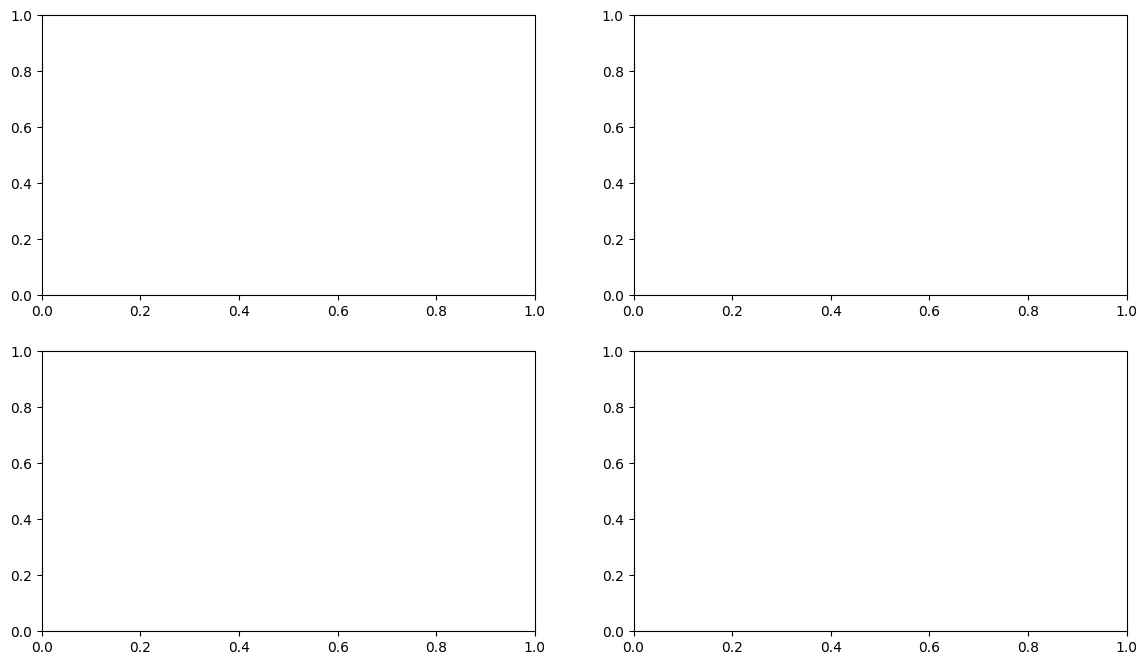

In [38]:
#Now, I will create the 4 plots

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

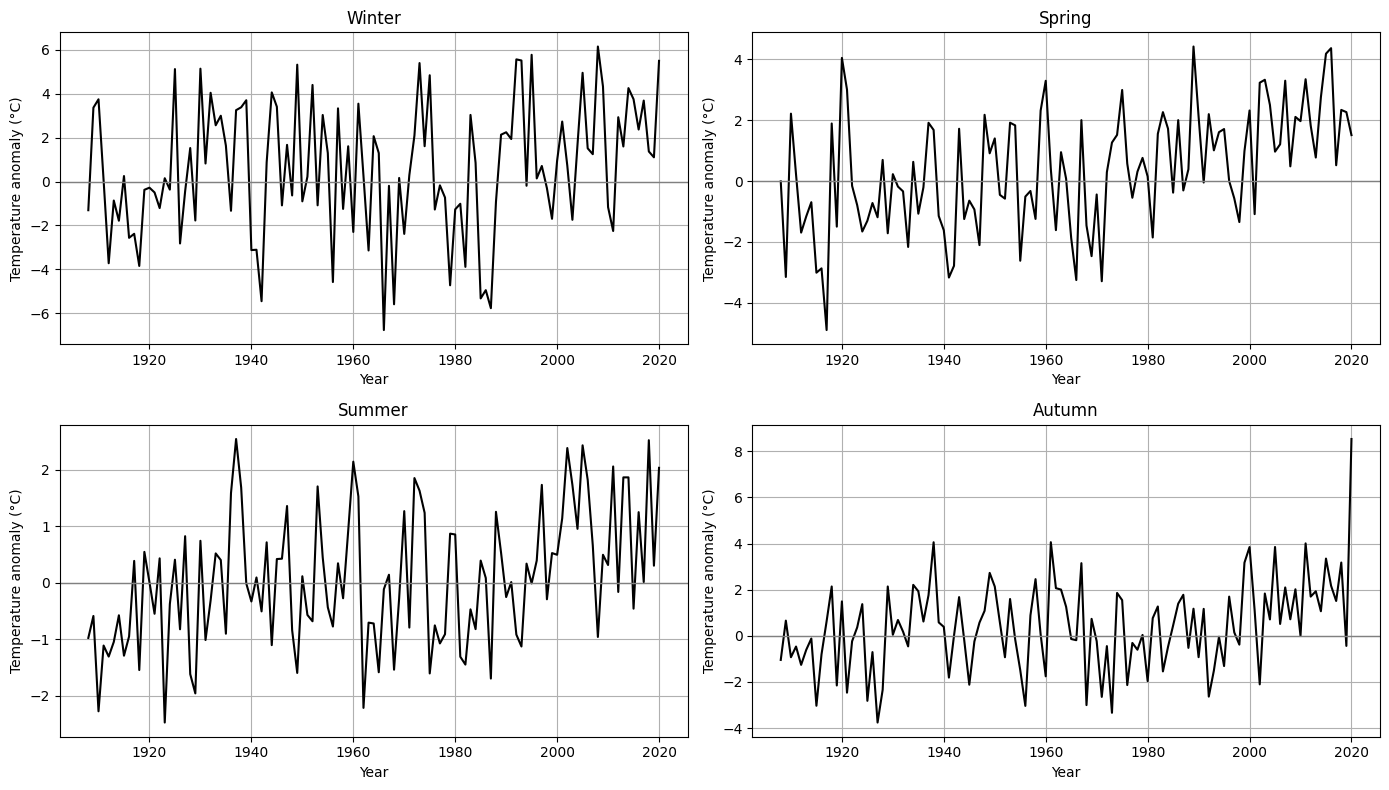

In [45]:
import matplotlib.pyplot as plt

# Create figure with 4 panels
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# create the seasons
seasons = ["Winter", "Spring", "Summer", "Autumn"]

# Make axes easier to use
axes = axes.flatten()

# Plot each season
for i in range(4):
    season = seasons[i]
    ax = axes[i]

    season_df = seasonal_data[seasonal_data["SEASON"] == season]

    ax.plot(season_df["SEASON_YEAR"],
            season_df["ANOMALY"],
            color="black")

    ax.axhline(0, color="gray", linewidth=1)
    ax.set_title(season)
    ax.set_xlabel("Year")
    ax.set_ylabel("Temperature anomaly (°C)")
    ax.grid(True)

plt.tight_layout()
plt.show()

AI statement:
used ChatGPT (OpenAI GPT-5.5) occasionally during this assignment when I encountered error messages or was unsure how to implement certain steps in Python. The tool was mainly used to explain concepts, help with debugging, and provide guidance on pandas and matplotlib functions. The code was written, tested, and adapted by me, and ChatGPT was used as a support tool rather than to complete the assignment for me.


Prompts used (translated from Dutch into English):

How can I calculate seasonal average temperatures using pandas?
How should December be handled when calculating winter temperatures?
How can I calculate temperature anomalies using a reference period?
How can I create a four-panel plot with matplotlib?

I also copied a few error messages into ChatGPT when I could not identify the problem myself. I received a n error when trying to calculate estimated temperatures because some columns were stored as strings instead of numeric values. ChatGPT helped explain the error and suggested converting the columns using pd.to_numeric(). Another example was a KeyError that occurred while creating the final seasonal anomaly plots. The issue was caused by a misspelled column name (SEASSON_YEAR instead of SEASON_YEAR). ChatGPT helped identify the source of the error and explain how to fix it.

The suggested code was sometimes modified by me before being used in the final notebook. The prompts were used to generate code for seasonal averages, winter year handling, temperature anomalies and the final plot. Some of the generated code was modified by me before being used.